In [ ]:
import json
from pathlib import Path

import numpy as np
from itertools import product
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, random_split

from energy_count import qaoa_energy
# !pip install pennylane
import pennylane as qml
from PL import create_qaoa_circuit, qaoa_expected_energy

import pandas as pd
import matplotlib.pyplot as plt

from collections import deque
import itertools
import pandas as pd
import numpy as np
import json
from pathlib import Path

## Helper Functions

In [2]:
def solve_qubo(Q):
    n = Q.shape[0]

    best_x = None
    worst_x = None

    min_energy = float("inf")
    max_energy = float("-inf")

    for x_tuple in product([0, 1], repeat=n):
        x = np.array(x_tuple, dtype=np.float32)
        energy = x @ Q @ x

        if energy < min_energy:
            min_energy = energy
            best_x = x

        if energy > max_energy:
            max_energy = energy
            worst_x = x

    return best_x, min_energy, worst_x, max_energy

In [3]:
def vectorize_matrix(Q):
    """
    Converts QUBO matrices to vectors using upper triangle with diagonal

    For n = 5: vector of length 15
    """
    upper_indices = np.triu_indices(5)
    vector = Q[upper_indices] # take elements from the upper triangle
    return vector

In [42]:
def load_dataset(folder_path):
    folder = Path(folder_path)

    X_vectors = []
    Q_matrices = []
    Emin_values = []
    Emax_values = []

    for file_path in sorted(folder.glob("*.json")):
        with open(file_path, "r") as file:
            item = json.load(file)

        Q = np.array(item["matrix"])

        vector = vectorize_matrix(Q) # transform to vector with upper triangle value

        best_x, Emin, worst_x, Emax = solve_qubo(Q)

        X_vectors.append(Q) # or .append(vector)
        Q_matrices.append(Q)
        Emin_values.append(Emin)
        Emax_values.append(Emax)

    X_vectors = np.array(X_vectors, dtype=np.float32)
    Q_matrices = np.array(Q_matrices, dtype=np.float32)
    Emin_values = np.array(Emin_values, dtype=np.float32)
    Emax_values = np.array(Emax_values, dtype=np.float32)

    return X_vectors, Q_matrices, Emin_values, Emax_values

In [5]:
def energy_loss(energy, Emin, Emax):
    loss = (energy - Emin) / (Emax - Emin)
    return loss

In [6]:
def split_params(params, p):
    ''' splits model output into beta and gamma parameters '''

    beta = params[:, :p]
    gamma = params[:, p:]

    return beta, gamma

## Dataset Preparation

The QUBO matrices are loaded from JSON files and converted to PyTorch tensors. The dataset is then split into train and test subsets (80/20).

In [43]:
X, Q, Emin, Emax = load_dataset("maxcut_qubo_dataset")
# print("X shape:", X.shape)
# print(X)

# convert all data to pytorch tensors and create one dataset
X_tensor = torch.tensor(X)
Q_tensor = torch.tensor(Q)
Emin_tensor = torch.tensor(Emin)
Emax_tensor = torch.tensor(Emax)

dataset = TensorDataset(X_tensor, Q_tensor, Emin_tensor, Emax_tensor)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(43)
)

print("Total dataset size:", len(dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Total dataset size: 100
Train size: 80
Test size: 20


## Model Definition

The model receives a vectorized QUBO matrix and predicts `2p` QAOA parameters.

In [37]:
def create_model(input_dim, p, seed):
    torch.manual_seed(seed)

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 2 * p)
    )

    return model

## Training Function


In [9]:
def train_model(seed, train_dataset, test_dataset, input_dim, p=2, num_epochs=10):
    model = create_model(input_dim, p, seed)
    optimizer = optim.SGD(model.parameters(), lr=0.001) # ???

    n = Q_tensor.shape[1]
    qaoa_circuit = create_qaoa_circuit(n, p)

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0

        for matrix_i, Q_i, Emin_i, Emax_i in train_dataset:
            optimizer.zero_grad()

            matrix_i = matrix_i.unsqueeze(0)

            params = model(matrix_i)
            beta, gamma = split_params(params, p)

            energy = qaoa_expected_energy(
                qubo=Q_i,
                beta=beta[0],
                gamma=gamma[0],
                qaoa_circuit=qaoa_circuit
            )

            loss = energy_loss(energy, Emin_i, Emax_i)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        avg_train_loss = total_train_loss / len(train_dataset)
        train_losses.append(avg_train_loss)

        model.eval()
        total_test_loss = 0

        with torch.no_grad():
            for matrix_i, Q_i, Emin_i, Emax_i in test_dataset:
                matrix_i = matrix_i.unsqueeze(0)

                params = model(matrix_i)
                beta, gamma = split_params(params, p)

                energy = qaoa_expected_energy(
                    qubo=Q_i,
                    beta=beta[0],
                    gamma=gamma[0],
                    qaoa_circuit=qaoa_circuit
                )

                loss = energy_loss(energy, Emin_i, Emax_i)

                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_dataset)
        test_losses.append(avg_test_loss)

        # print(
        #     f"Epoch {epoch + 1}/{num_epochs} | "
        #     f"train loss: {avg_train_loss:.4f} | "
        #     f"test loss: {avg_test_loss:.4f}"
        # )

    return {
        "model": model,
        "seed": seed,
        "start_train_loss": train_losses[0],
        "start_test_loss": test_losses[0],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
        "train_losses": train_losses,
        "test_losses": test_losses
    }

## Effect of Seed

The QAOA depth `p` is fixed and the model is trained with several seeds.

In [ ]:
# p_fixed = 3
# seeds = [i for i in range(1, 31)]

# results = []

# input_dim = X_tensor[0].numel()

# for seed in seeds:
#     result = train_model(
#         seed=seed,
#         train_dataset=train_dataset,
#         test_dataset=test_dataset,
#         input_dim=input_dim,
#         p=p_fixed,
#         num_epochs=50
#     )

#     results.append(result)

#     print(
#         f"seed={seed} | "
#         f"train loss={result['final_train_loss']:.4f} | "
#         f"test loss={result['final_test_loss']:.4f}"
#     )


seed=1 | train loss=0.1180 | test loss=0.1248
seed=2 | train loss=0.1166 | test loss=0.1254
seed=3 | train loss=0.1184 | test loss=0.1276
seed=4 | train loss=0.1176 | test loss=0.1216
seed=5 | train loss=0.1179 | test loss=0.1269
seed=6 | train loss=0.1171 | test loss=0.1243
seed=7 | train loss=0.1177 | test loss=0.1235
seed=8 | train loss=0.1167 | test loss=0.1227
seed=9 | train loss=0.1165 | test loss=0.1219
seed=10 | train loss=0.1175 | test loss=0.1243
seed=11 | train loss=0.1176 | test loss=0.1230
seed=12 | train loss=0.1173 | test loss=0.1251
seed=13 | train loss=0.1164 | test loss=0.1233
seed=14 | train loss=0.1255 | test loss=0.1302
seed=15 | train loss=0.1188 | test loss=0.1260
seed=16 | train loss=0.1172 | test loss=0.1254
seed=17 | train loss=0.1163 | test loss=0.1251
seed=18 | train loss=0.1177 | test loss=0.1235
seed=19 | train loss=0.1171 | test loss=0.1251
seed=20 | train loss=0.1174 | test loss=0.1240
seed=21 | train loss=0.1165 | test loss=0.1261
seed=22 | train loss=0

### Plot: Final Train Loss by Seed

The x-axis shows the seed. The y-axis shows the final average train loss for last epoch.

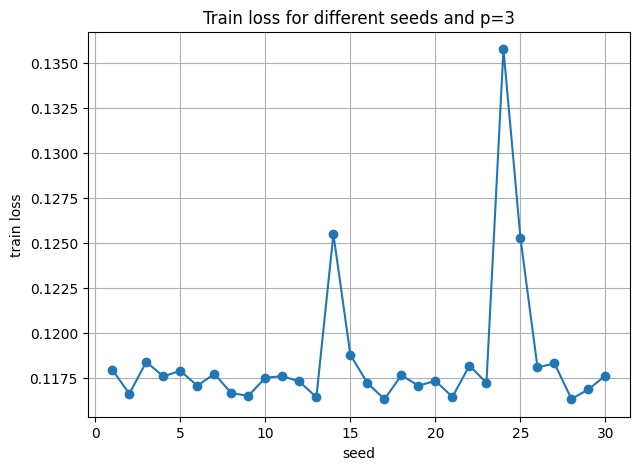

In [11]:
results_table = pd.DataFrame([
    {
        "seed": result["seed"],
        "train_loss": result["final_train_loss"]
    }
    for result in results
])

plt.figure(figsize=(7, 5))

plt.plot(
    results_table["seed"],
    results_table["train_loss"],
    marker="o"
)

plt.xlabel("seed")
plt.ylabel("train loss")
plt.title(f"Train loss for different seeds and p={p_fixed}")
plt.grid(True)

plt.show()

## Effect of QAOA Depth `p`

Here the random seed is fixed, and models are trained for different p. 

In [12]:
p_values = [i for i in range(1, 7)]

p_results = []

input_dim = X_tensor[0].numel()

for p_curr in p_values:

    result = train_model(
        seed=43,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        input_dim=input_dim,
        p=p_curr,
        num_epochs=50
    )

    p_results.append({
        "p": p_curr,
        "train_loss": result["final_train_loss"],
        "test_loss": result["final_test_loss"]
    })

    print(
        f"p={p_curr} | "
        f"final train loss={result['final_train_loss']:.4f} | "
        f"final test loss={result['final_test_loss']:.4f}"
    )

p=1 | final train loss=0.3887 | final test loss=0.4075
p=2 | final train loss=0.1865 | final test loss=0.2042
p=3 | final train loss=0.1173 | final test loss=0.1233
p=4 | final train loss=0.0873 | final test loss=0.0937
p=5 | final train loss=0.0591 | final test loss=0.0651
p=6 | final train loss=0.0542 | final test loss=0.0681


### Plot: Final Train Loss by QAOA Depth

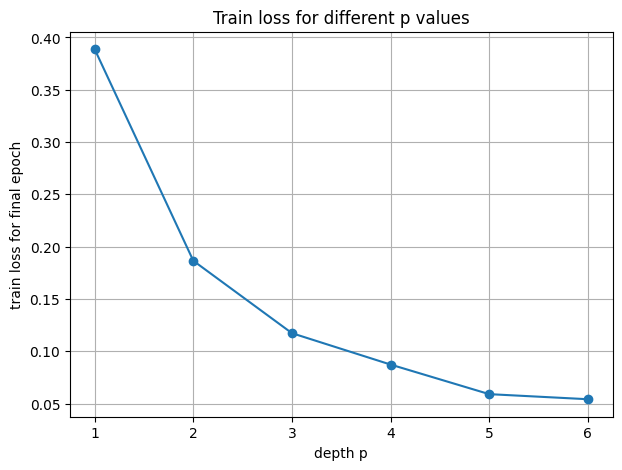

In [13]:
p_results_table = pd.DataFrame(p_results)
plt.figure(figsize=(7, 5))

plt.plot(
    p_results_table["p"],
    p_results_table["train_loss"],
    marker="o"
)

plt.xlabel("depth p")
plt.ylabel("train loss for final epoch")
plt.title("Train loss for different p values")
plt.grid(True)

plt.show()

### Plot: Final Test Loss by QAOA Depth

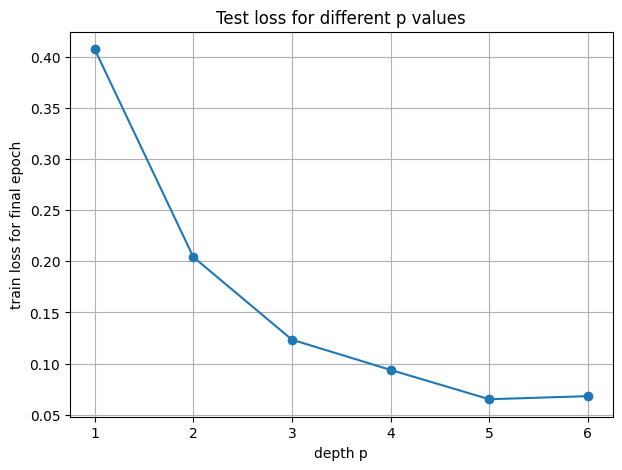

In [14]:
plt.figure(figsize=(7, 5))

plt.plot(
    p_results_table["p"],
    p_results_table["test_loss"],
    marker="o"
)

plt.xlabel("depth p")
plt.ylabel("train loss for final epoch")
plt.title("Test loss for different p values")
plt.grid(True)

plt.show()

## Loss by individual matrix with fixed `p`

After training model with fixed p, the trained model is evaluated on each matrix separately.

### Train Model with fixed `p`

In [44]:
p_fixed = 3
seed = 43

test_model = train_model(
    seed=seed,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    input_dim=input_dim,
    p=p_fixed,
    num_epochs=50
)

### Compute Per-Matrix Losses


In [45]:
trained_model = test_model["model"]

n = Q_tensor.shape[1]
qaoa_circuit = create_qaoa_circuit(n, p_fixed)

trained_model.eval()

train_matrix_losses = []
test_matrix_losses = []

with torch.no_grad():

    # for train data
    for idx, (matrix_i, Q_i, Emin_i, Emax_i) in enumerate(train_dataset):
        matrix_i = matrix_i.unsqueeze(0)

        params = trained_model(matrix_i)

        beta, gamma = split_params(params, p_fixed)

        energy = qaoa_expected_energy(
            qubo=Q_i,
            beta=beta[0],
            gamma=gamma[0],
            qaoa_circuit=qaoa_circuit
        )

        loss = energy_loss(energy, Emin_i, Emax_i)

        train_matrix_losses.append(loss.item())

    # for test data
    for idx, (matrix_i, Q_i, Emin_i, Emax_i) in enumerate(test_dataset):
        matrix_i = matrix_i.unsqueeze(0)

        params = trained_model(matrix_i)

        beta, gamma = split_params(params, p_fixed)

        energy = qaoa_expected_energy(
            qubo=Q_i,
            beta=beta[0],
            gamma=gamma[0],
            qaoa_circuit=qaoa_circuit
        )

        loss = energy_loss(energy, Emin_i, Emax_i)

        test_matrix_losses.append(loss.item())

### Plot: Train Loss by Matrix

The x-axis is the matrix number inside the train dataset. The y-axis is the loss value obtained by the trained model for this matrix.

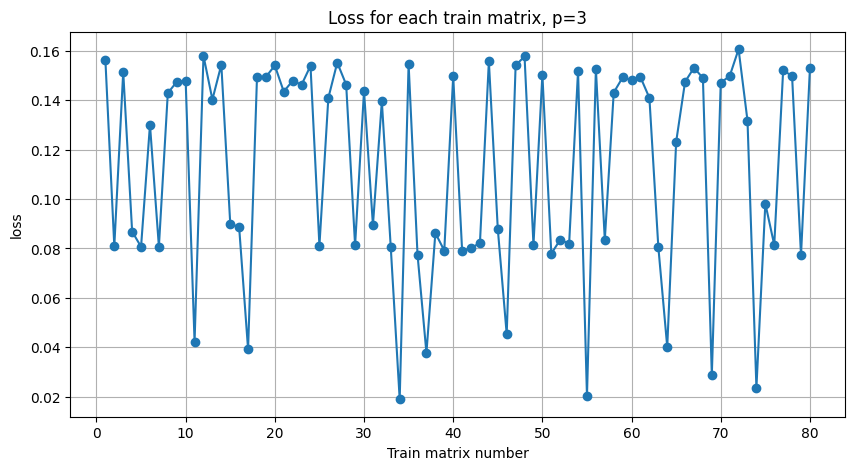

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_matrix_losses) + 1),
    train_matrix_losses,
    marker="o"
)

plt.xlabel("Train matrix number")
plt.ylabel("loss")
plt.title(f"Loss for each train matrix, p={p_fixed}")
plt.grid(True)

plt.show()
# show initial loss for per matrix 

### Plot: Test Loss by Matrix

The x-axis is the matrix number inside the test dataset. The y-axis is the loss value obtained by the trained model for this matrix.

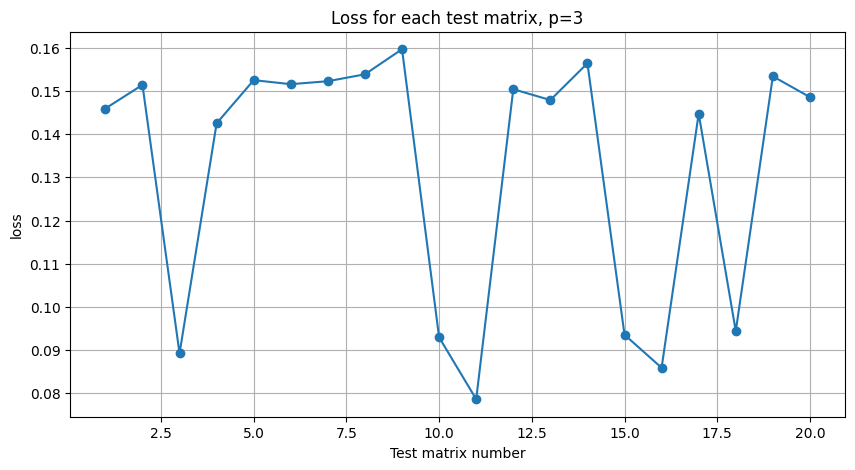

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(test_matrix_losses) + 1),
    test_matrix_losses,
    marker="o"
)

plt.xlabel("Test matrix number")
plt.ylabel("loss")
plt.title(f"Loss for each test matrix, p={p_fixed}")
plt.grid(True)

plt.show()

In [ ]:
json_folder = Path("maxcut_qubo_dataset")
json_files = sorted(json_folder.glob("*.json"))

low_threshold = 0.05
middle_threshold = 0.10

group_1 = []
group_2 = []
group_3 = []

for train_idx, loss_value in enumerate(train_matrix_losses, start=1):

    # train_idx is number on the plot
    # dataset_idx is original index in the full dataset
    dataset_idx = train_dataset.indices[train_idx - 1]
    json_file = json_files[dataset_idx]

    rec = {
        "train_matrix_number": train_idx,
        "dataset_index": dataset_idx,
        "json_file": json_file.name,
        "loss": loss_value
    }

    if loss_value <= low_threshold:
        group_1.append(rec)
    elif loss_value <= middle_threshold:
        group_2.append(rec)
    else:
        group_3.append(rec)


print("Group 1: loss <= 0.05")
print([item["train_matrix_number"] for item in group_1])

print("\nGroup 2: 0.05 < loss <= 0.10")
print([item["train_matrix_number"] for item in group_2])

print("\nGroup 3: loss > 0.10")
print([item["train_matrix_number"] for item in group_3])

Group 1: loss <= 0.05
[11, 17, 34, 37, 46, 55, 64, 69, 74]

Group 2: 0.05 < loss <= 0.10
[2, 4, 5, 7, 15, 16, 25, 29, 31, 33, 36, 38, 39, 41, 42, 43, 45, 49, 51, 52, 53, 57, 63, 75, 76, 79]

Group 3: loss > 0.10
[1, 3, 6, 8, 9, 10, 12, 13, 14, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 30, 32, 35, 40, 44, 47, 48, 50, 54, 56, 58, 59, 60, 61, 62, 65, 66, 67, 68, 70, 71, 72, 73, 77, 78, 80]


In [ ]:
from math import ceil

def load_edges_from_json(json_file):
    with open(json_file, "r", encoding="utf-8") as f:
        item = json.load(f)

    edges = item["edges"]
    n = item["n"]

    return edges, n


# draw one graph on a given subplot
def draw_graph(edges, n, ax, title):
    # place nodes on a circle
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    positions = {
        node: (np.cos(angle), np.sin(angle))
        for node, angle in enumerate(angles)
    }

    # draw graph edges
    for i, j in edges:
        x_values = [positions[i][0], positions[j][0]]
        y_values = [positions[i][1], positions[j][1]]

        ax.plot(
            x_values,
            y_values,
            linewidth=1.5,
            color="gray",
            zorder=1
        )

    # get node coordinates
    x_nodes = [positions[node][0] for node in range(n)]
    y_nodes = [positions[node][1] for node in range(n)]

    # draw graph nodes
    ax.scatter(
        x_nodes,
        y_nodes,
        s=500,
        color="white",
        edgecolors="black",
        linewidths=1.5,
        zorder=2
    )

    # add node labels
    for node in range(n):
        x, y = positions[node]
        ax.text(
            x,
            y,
            str(node),
            ha="center",
            va="center",
            fontsize=10,
            zorder=3
        )

    # format subplot
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")


# plot all graphs from one loss group
def plot_graph_group(group, group_title):

    # set number of columns and rows for subplots
    cols = 5
    rows = ceil(len(group) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

    axes = axes.flatten()

    # hide unused subplots
    for ax in axes[len(group):]:
        ax.axis("off")

    # draw each graph in the group
    for ax, item in zip(axes, group):
        json_file = json_folder / item["json_file"]

        edges, n = load_edges_from_json(json_file)

        title = (
            f"train #{item['train_matrix_number']}\n"
            f"{item['json_file']}\n"
            f"loss={item['loss']:.4f}"
        )

        draw_graph(edges, n, ax, title)

    plt.suptitle(group_title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

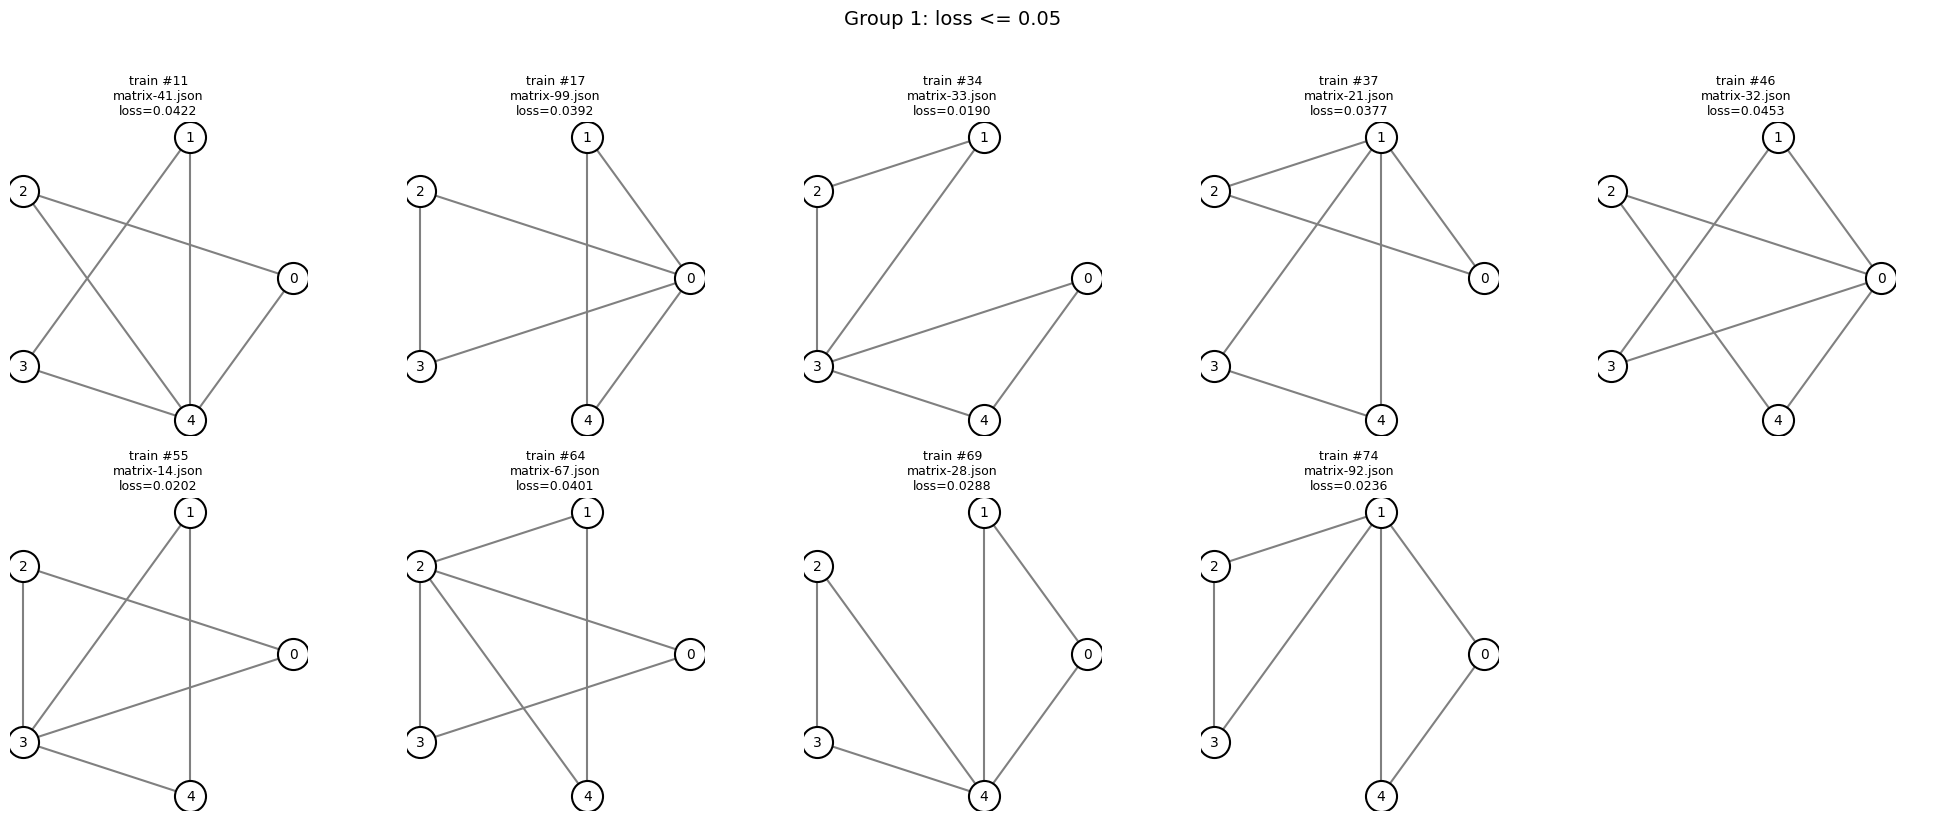

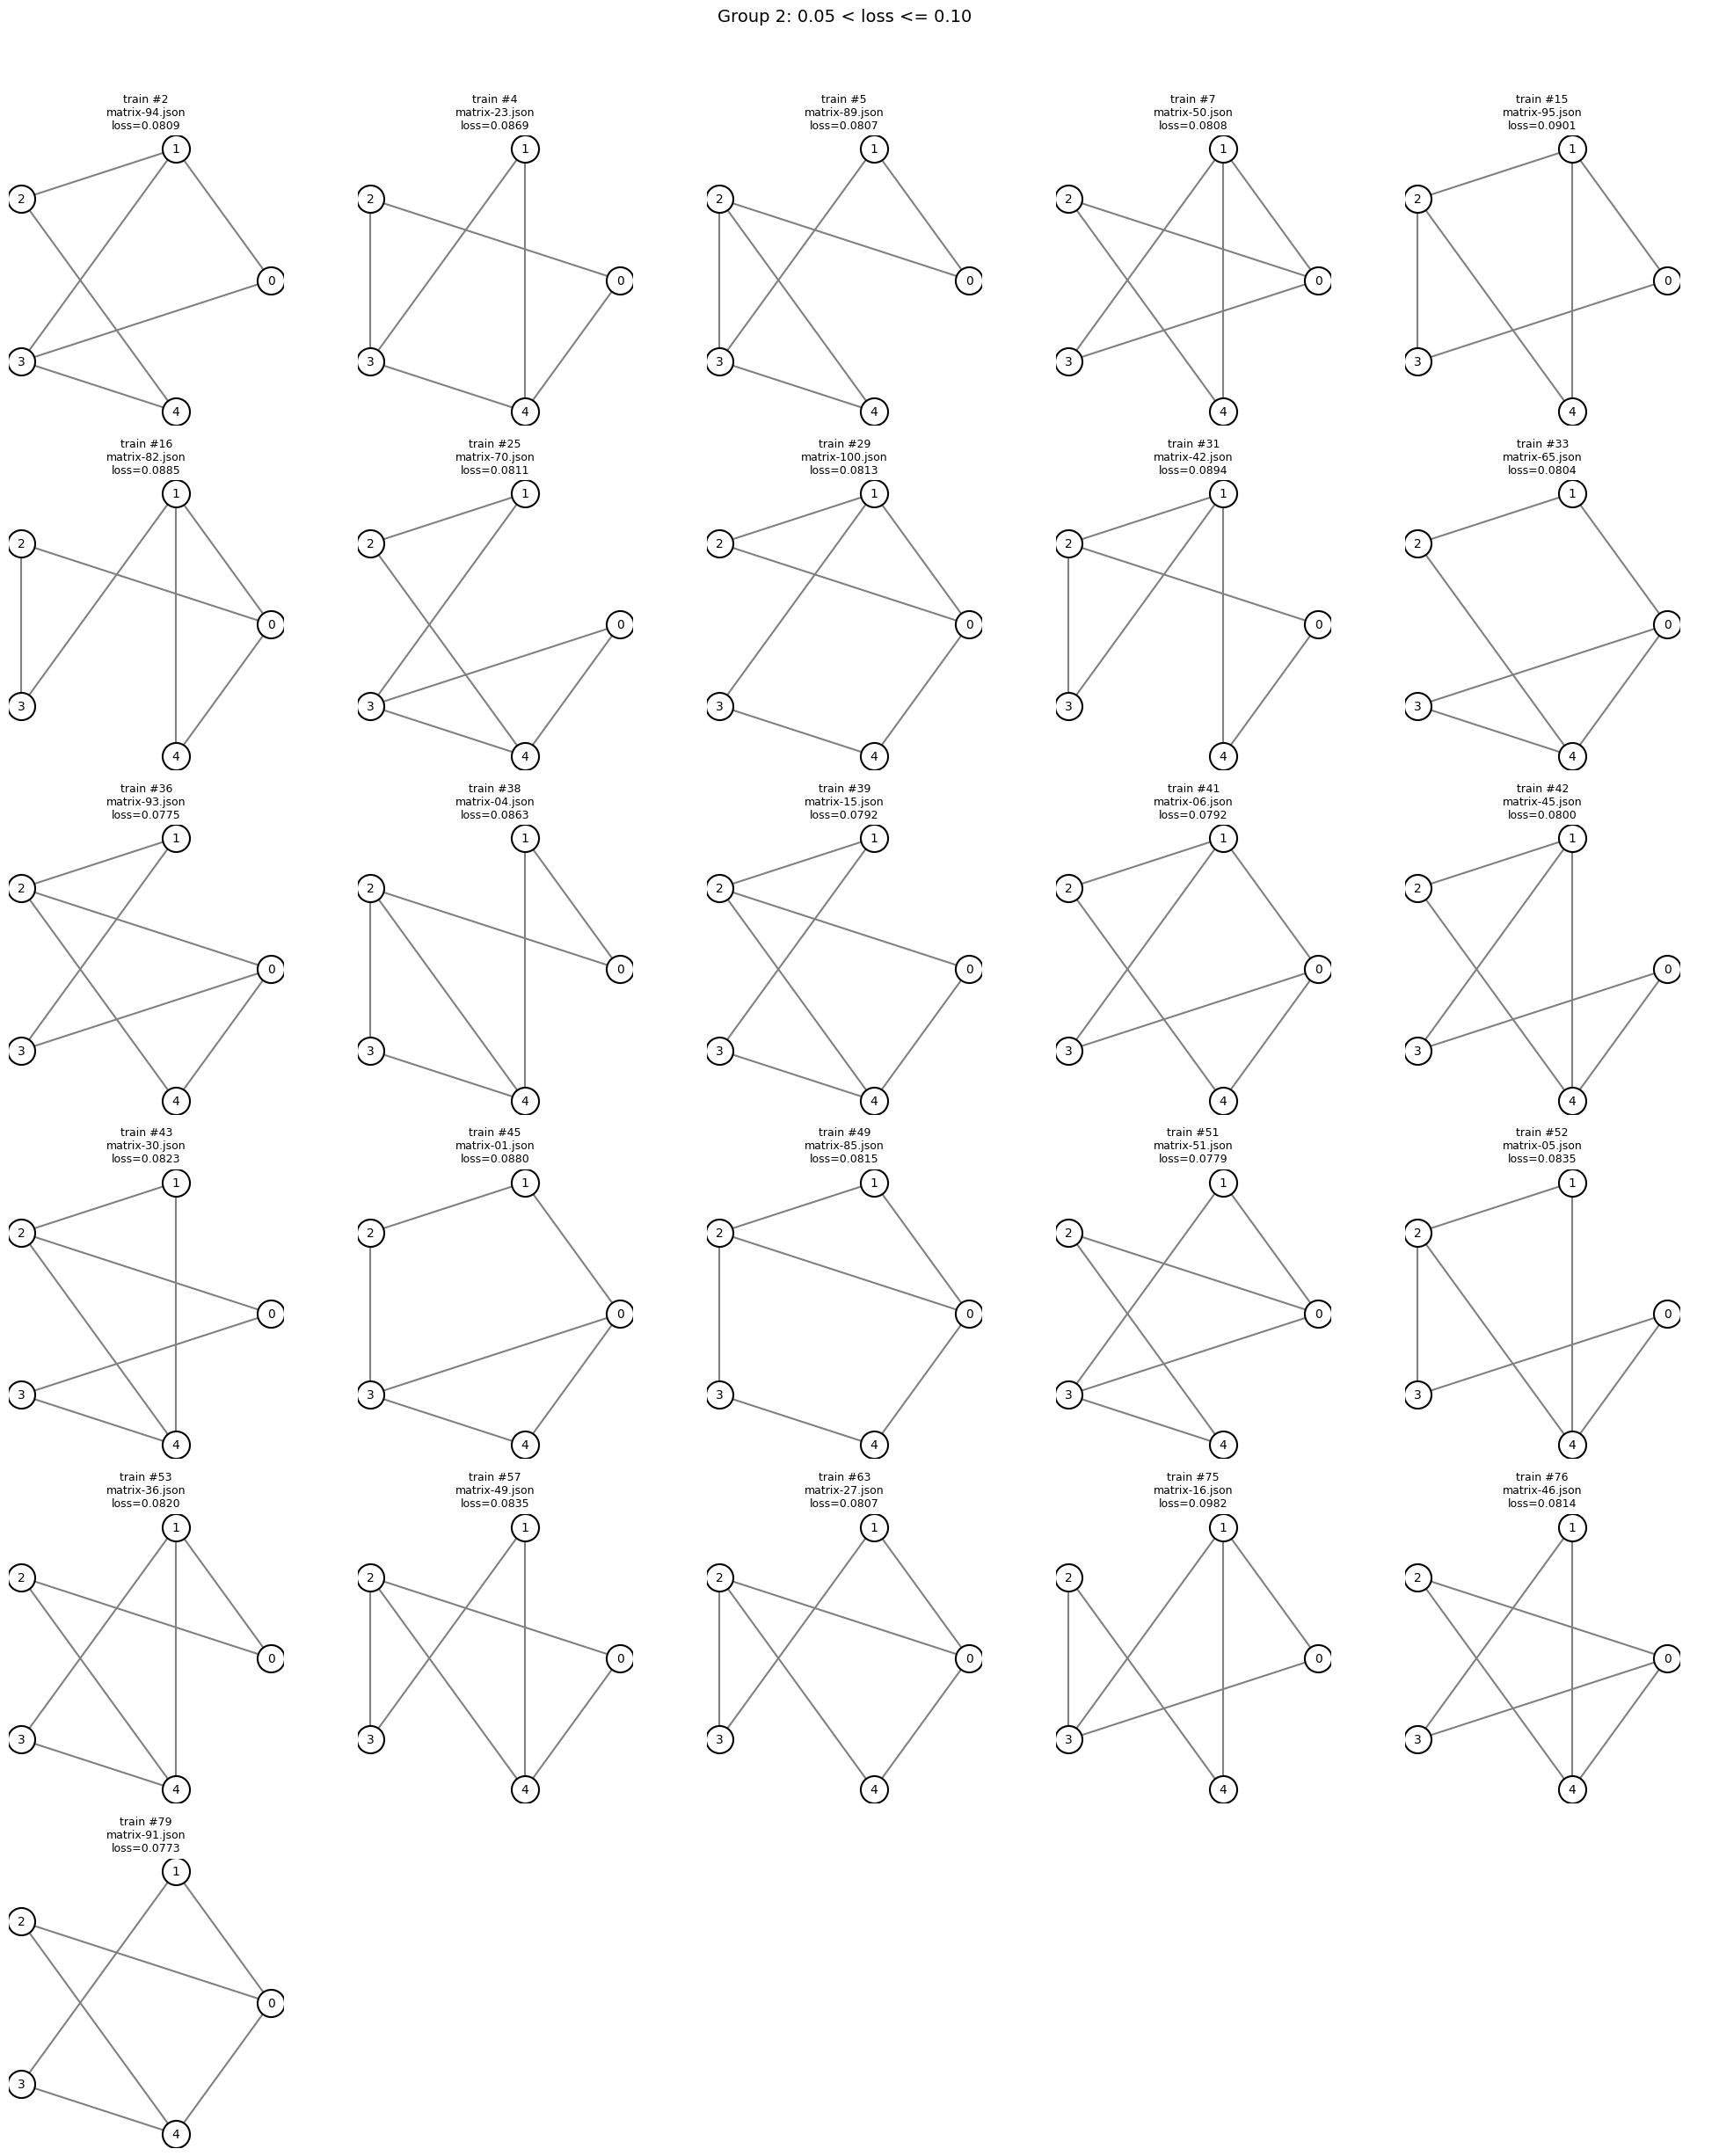

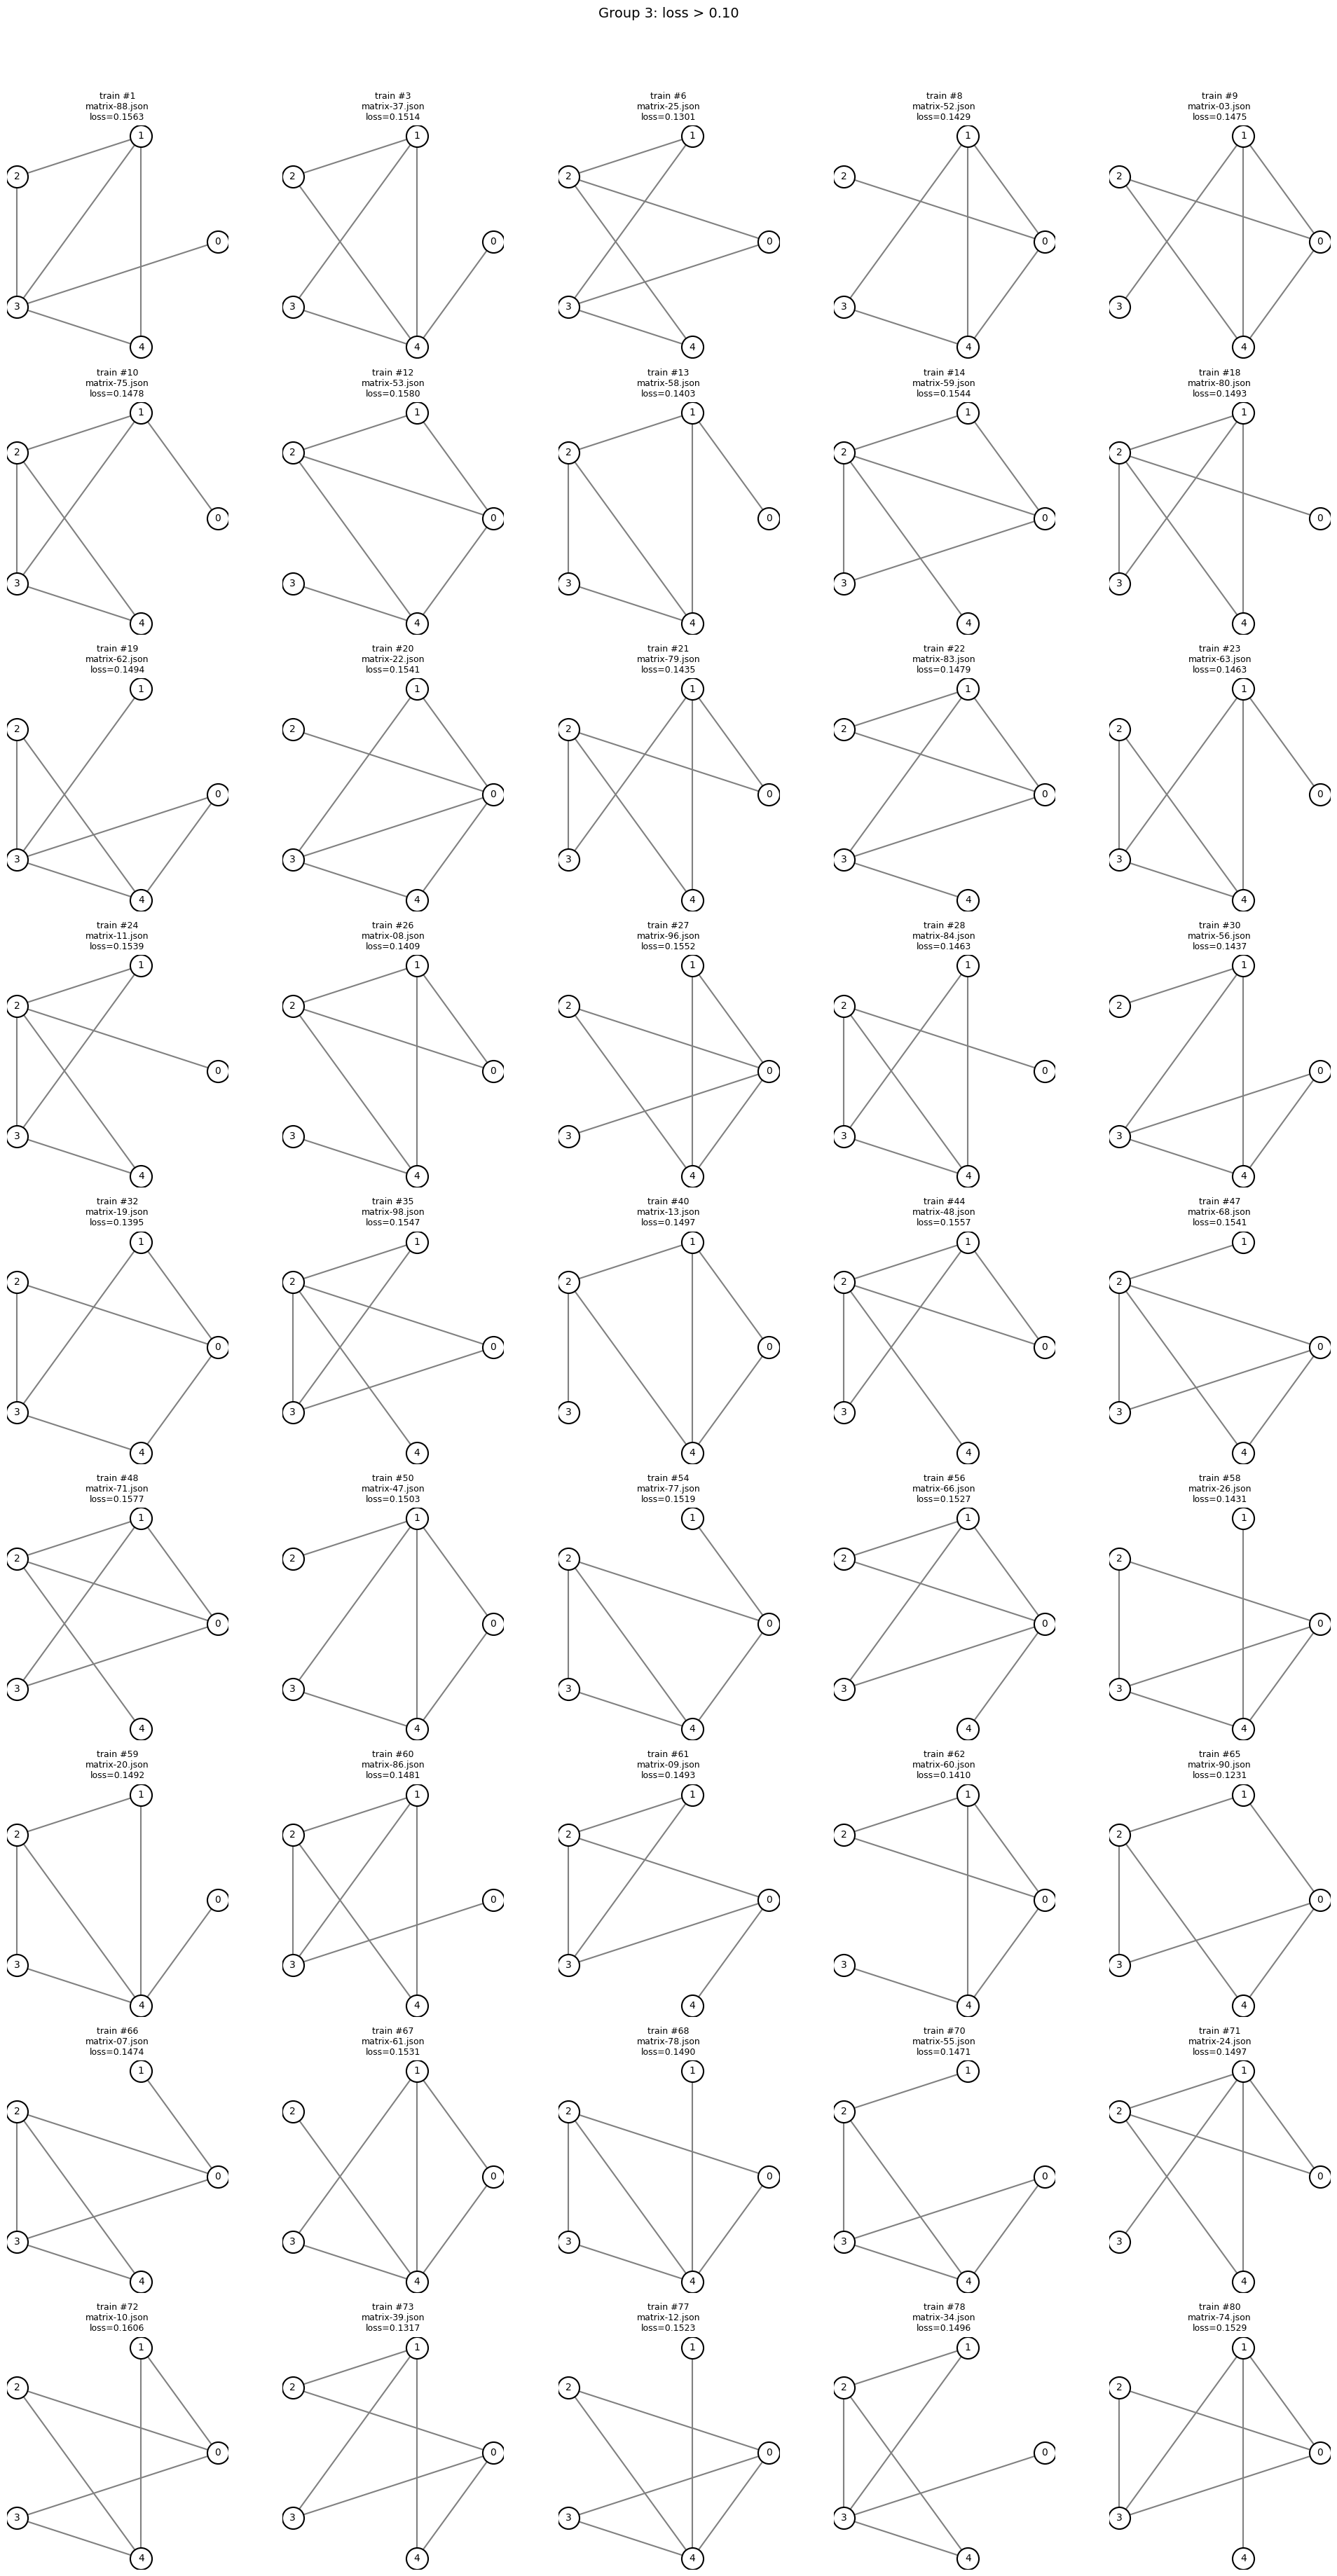

In [66]:
plot_graph_group(group_1, "Group 1: loss <= 0.05")
plot_graph_group(group_2, "Group 2: 0.05 < loss <= 0.10")
plot_graph_group(group_3, "Group 3: loss > 0.10")

In [76]:
def get_loss_group(loss_value):
    if loss_value <= 0.05:
        return "group 1: low loss"
    elif loss_value <= 0.10:
        return "group 2: middle loss"
    else:
        return "group 3: high loss"


def build_adj_matrix(n, edges):
    adj = np.zeros((n, n), dtype=int)

    for i, j in edges:
        adj[i, j] = 1
        adj[j, i] = 1

    return adj


def degree_sequence(n, edges):
    degree = [0] * n

    for i, j in edges:
        degree[i] += 1
        degree[j] += 1

    return tuple(sorted(degree, reverse=True))


def count_triangles(n, edges):
    edge_set = {tuple(sorted(edge)) for edge in edges}
    triangles = 0

    for a, b, c in itertools.combinations(range(n), 3):
        if (
            tuple(sorted((a, b))) in edge_set
            and tuple(sorted((a, c))) in edge_set
            and tuple(sorted((b, c))) in edge_set
        ):
            triangles += 1

    return triangles



def max_cut_info(n, edges):
    best_cut_size = -1
    num_optimal_cuts = 0

    for bits in itertools.product([0, 1], repeat=n):
        cut_size = 0

        for i, j in edges:
            if bits[i] != bits[j]:
                cut_size += 1

        if cut_size > best_cut_size:
            best_cut_size = cut_size
            num_optimal_cuts = 1
        elif cut_size == best_cut_size:
            num_optimal_cuts += 1

    return best_cut_size, num_optimal_cuts



graph_analysis_records = []

for train_idx, loss_value in enumerate(train_matrix_losses, start=1):
    dataset_idx = train_dataset.indices[train_idx - 1]
    json_file = json_files[dataset_idx]

    with open(json_file, "r", encoding="utf-8") as f:
        item = json.load(f)

    n = item["n"]
    edges = [tuple(edge) for edge in item["edges"]]

    deg_seq = degree_sequence(n, edges)
    max_cut_size, num_optimal_cuts = max_cut_info(n, edges)

    graph_analysis_records.append({
        "train_matrix_number": train_idx,
        "dataset_index": dataset_idx,
        "json_file": json_file.name,
        "loss": loss_value,
        "loss_group": get_loss_group(loss_value),
        "degree_sequence": deg_seq,
        "max_degree": max(deg_seq),
        "min_degree": min(deg_seq),
        "triangles": count_triangles(n, edges),
        "max_cut_size": max_cut_size,
        "num_optimal_cuts": num_optimal_cuts,
        "edges": edges
    })

graph_analysis_df = pd.DataFrame(graph_analysis_records)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(graph_analysis_df.sort_values("loss"))

,train_matrix_number,dataset_index,json_file,loss,loss_group,degree_sequence,max_degree,min_degree,triangles,max_cut_size,num_optimal_cuts,edges
33,34,33,matrix-33.json,0.018976,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(2, 3), (0, 3), (1, 2), (3, 4), (1, 3), (0, 4)]"
54,55,14,matrix-14.json,0.020243,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(1, 3), (0, 3), (0, 2), (1, 4), (3, 4), (2, 3)]"
73,74,92,matrix-92.json,0.023607,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(1, 4), (0, 1), (1, 2), (2, 3), (1, 3), (0, 4)]"
68,69,28,matrix-28.json,0.028819,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(3, 4), (1, 4), (0, 4), (2, 3), (2, 4), (0, 1)]"
36,37,21,matrix-21.json,0.037697,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(1, 3), (1, 4), (3, 4), (0, 1), (0, 2), (1, 2)]"
16,17,99,matrix-99.json,0.039186,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(1, 4), (0, 4), (0, 1), (2, 3), (0, 2), (0, 3)]"
63,64,67,matrix-67.json,0.040134,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(2, 4), (0, 2), (1, 4), (0, 3), (2, 3), (1, 2)]"
10,11,41,matrix-41.json,0.042188,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(1, 3), (3, 4), (0, 2), (1, 4), (0, 4), (2, 4)]"
45,46,32,matrix-32.json,0.045290,group 1: low loss,"(4, 2, 2, 2, 2)",4,2,2,4,18,"[(0, 3), (1, 3), (0, 4), (0, 1), (2, 4), (0, 2)]"
78,79,91,matrix-91.json,0.077279,group 2: middle loss,"(3, 3, 2, 2, 2)",3,2,1,5,4,"[(2, 4), (0, 1), (0, 2), (0, 4), (1, 3), (3, 4)]"


In [74]:
group_summary = graph_analysis_df.groupby("loss_group").agg(
    count=("loss", "size"),
    mean_loss=("loss", "mean"),
    mean_triangles=("triangles", "mean"),
    mean_max_degree=("max_degree", "mean"),
    mean_max_cut_size=("max_cut_size", "mean"),
    mean_num_optimal_cuts=("num_optimal_cuts", "mean"),
).reset_index()

display(group_summary)

,loss_group,count,mean_loss,mean_triangles,mean_max_degree,mean_max_cut_size,mean_num_optimal_cuts
0,group 1: low loss,9,0.032905,2.000000,4.000000,4.000000,18.0
1,group 2: middle loss,26,0.083010,1.000000,3.000000,5.000000,4.0
2,group 3: high loss,45,0.148285,1.733333,3.422222,5.133333,2.0


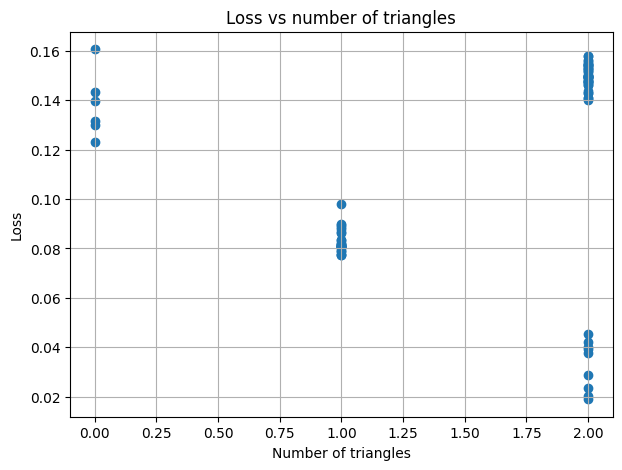

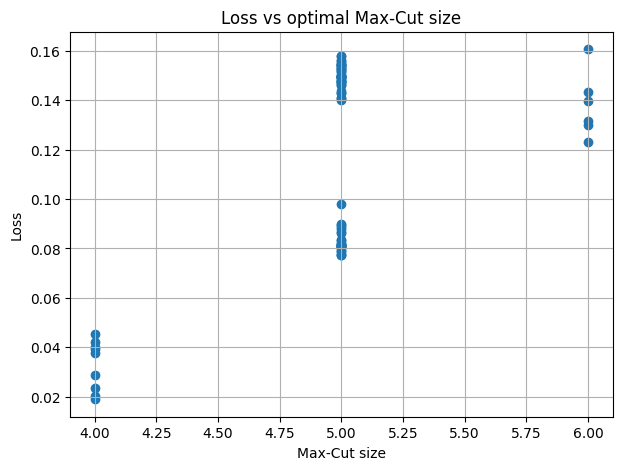

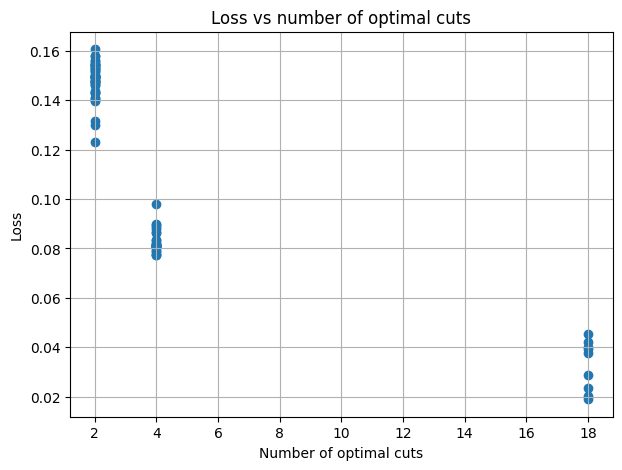

In [75]:
plt.figure(figsize=(7, 5))
plt.scatter(graph_analysis_df["triangles"], graph_analysis_df["loss"])
plt.xlabel("Number of triangles")
plt.ylabel("Loss")
plt.title("Loss vs number of triangles")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(graph_analysis_df["max_cut_size"], graph_analysis_df["loss"])
plt.xlabel("Max-Cut size")
plt.ylabel("Loss")
plt.title("Loss vs optimal Max-Cut size")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(graph_analysis_df["num_optimal_cuts"], graph_analysis_df["loss"])
plt.xlabel("Number of optimal cuts")
plt.ylabel("Loss")
plt.title("Loss vs number of optimal cuts")
plt.grid(True)
plt.show()

## Multi-Seed × Multi-p Experiment

Train the model for each combination of `p ∈ {1..5}` and `seed ∈ {9, 13, 17, 28, 24}`.
Seeds 9, 13, 17, 28 were selected as consistently best-performing from the seed sweep above.
Seed 24 is included as a reference (worst performer in that sweep).

For each trained model, all 205 matrices are evaluated.
The **min energy** for each matrix is defined as the average QUBO energy
of the **top-10 most probable bitstrings** returned by the QAOA circuit.

### Helper: Top-K Average Energy

In [ ]:
def bitstrings_tensor_full(n, dtype=torch.float32):
    bits = [[int(b) for b in f"{i:0{n}b}"] for i in range(2 ** n)]
    return torch.tensor(bits, dtype=dtype)


def top_k_avg_energy(qubo, probs, k=10):
    """
    Returns the average QUBO energy of the k most probable bitstrings.
    qubo: [n, n] tensor
    probs: [2**n] tensor (output of qaoa_circuit)
    """
    n = qubo.shape[0]
    bits = bitstrings_tensor_full(n, dtype=qubo.dtype)  # [2**n, n]
    top_indices = torch.topk(probs, k).indices           # [k]
    top_bits = bits[top_indices]                          # [k, n]
    energies = torch.stack([x @ qubo @ x for x in top_bits])
    return energies.mean().item()


### Config

In [ ]:
EXP_P_VALUES = [1, 2, 3, 4, 5]
EXP_SEEDS    = [9, 13, 17, 28, 24]   # 9/13/17/28 = best from seed sweep; 24 = reference
EXP_EPOCHS   = 50
TOP_K        = 10

SEED_COLORS = {
    9:  "#1f77b4",
    13: "#2ca02c",
    17: "#ff7f0e",
    28: "#9467bd",
    24: "#d62728",   # red = reference
}
SEED_LABELS = {s: (f"seed={s}" if s != 24 else f"seed={s} (ref)") for s in EXP_SEEDS}


### Run Experiment

For each `(p, seed)` pair: train the model, then evaluate all 205 matrices.

In [ ]:
import time

exp_results = []

input_dim = X_tensor[0].numel()
n_qubits  = Q_tensor.shape[1]

for p_curr in EXP_P_VALUES:
    for seed_curr in EXP_SEEDS:
        t0 = time.time()

        result = train_model(
            seed=seed_curr,
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            input_dim=input_dim,
            p=p_curr,
            num_epochs=EXP_EPOCHS,
        )

        model_curr   = result["model"]
        circuit_curr = create_qaoa_circuit(n_qubits, p_curr)

        # evaluate all 205 matrices
        model_curr.eval()
        matrix_records = []

        with torch.no_grad():
            for i in range(len(X_tensor)):
                X_i    = X_tensor[i].unsqueeze(0)
                Q_i    = Q_tensor[i]
                Emin_i = Emin_tensor[i].item()
                Emax_i = Emax_tensor[i].item()

                params      = model_curr(X_i)
                beta, gamma = split_params(params, p_curr)
                probs       = circuit_curr(beta[0], gamma[0], Q_i)

                min_energy  = top_k_avg_energy(Q_i, probs, TOP_K)
                norm_energy = (min_energy - Emin_i) / (Emax_i - Emin_i)

                matrix_records.append({
                    "matrix_idx":  i,
                    "Emin":        Emin_i,
                    "Emax":        Emax_i,
                    "min_energy":  min_energy,
                    "norm_energy": norm_energy,
                })

        exp_results.append({
            "p":            p_curr,
            "seed":         seed_curr,
            "train_losses": result["train_losses"],
            "test_losses":  result["test_losses"],
            "matrices":     matrix_records,
        })

        elapsed = time.time() - t0
        print(
            f"p={p_curr}, seed={seed_curr} | "
            f"train={result['final_train_loss']:.4f}, "
            f"test={result['final_test_loss']:.4f} | "
            f"{elapsed:.0f}s"
        )


In [ ]:
def lookup(p, seed):
    for r in exp_results:
        if r["p"] == p and r["seed"] == seed:
            return r
    return None


### Plot: Final Train & Test Loss vs p

One line per seed. Dashed red = reference seed 24.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for seed in EXP_SEEDS:
    train_finals = [lookup(p, seed)["train_losses"][-1] for p in EXP_P_VALUES]
    test_finals  = [lookup(p, seed)["test_losses"][-1]  for p in EXP_P_VALUES]
    ls    = "--" if seed == 24 else "-"
    color = SEED_COLORS[seed]
    label = SEED_LABELS[seed]

    axes[0].plot(EXP_P_VALUES, train_finals, marker="o", color=color, linestyle=ls, label=label)
    axes[1].plot(EXP_P_VALUES, test_finals,  marker="o", color=color, linestyle=ls, label=label)

for ax, title in zip(axes, ["Final Train Loss vs p", "Final Test Loss vs p"]):
    ax.set_xlabel("QAOA depth p")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle("Final Loss by QAOA Depth and Seed", fontsize=13)
plt.tight_layout()
plt.show()


### Plot: Normalized Energy per Matrix

For each `p`, one subplot showing norm_energy for all 205 matrices, one line per seed.

In [ ]:
fig, axes = plt.subplots(len(EXP_P_VALUES), 1, figsize=(14, 4 * len(EXP_P_VALUES)), sharex=True)

for ax, p in zip(axes, EXP_P_VALUES):
    for seed in EXP_SEEDS:
        rec = lookup(p, seed)
        norm_energies = [m["norm_energy"] for m in rec["matrices"]]
        ax.plot(
            range(1, len(norm_energies) + 1),
            norm_energies,
            linewidth=0.8, alpha=0.8,
            color=SEED_COLORS[seed],
            linestyle="--" if seed == 24 else "-",
            label=SEED_LABELS[seed],
        )
    ax.set_title(f"Normalized Energy per Matrix  (p={p})", fontsize=10)
    ax.set_ylabel("norm energy")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, linewidth=0.4)

axes[-1].set_xlabel("Matrix index")
plt.suptitle("Top-10 Avg Energy (normalized) — All 205 Matrices", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


### Plot: Distribution of Normalized Energy (Boxplot)

Grouped by `p`, one box per seed per `p`.

In [ ]:
n_seeds = len(EXP_SEEDS)
width   = 0.15
x       = np.arange(len(EXP_P_VALUES))

fig, ax = plt.subplots(figsize=(12, 6))

for i, seed in enumerate(EXP_SEEDS):
    data_per_p = [[m["norm_energy"] for m in lookup(p, seed)["matrices"]] for p in EXP_P_VALUES]
    offsets = x + (i - n_seeds / 2 + 0.5) * width
    bp = ax.boxplot(
        data_per_p,
        positions=offsets,
        widths=width * 0.9,
        patch_artist=True,
        manage_ticks=False,
    )
    color = SEED_COLORS[seed]
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for elem in ["whiskers", "caps", "medians", "fliers"]:
        for item in bp[elem]:
            item.set_color(color)
    ax.plot([], [], color=color, label=SEED_LABELS[seed], linewidth=3)

ax.set_xticks(x)
ax.set_xticklabels([f"p={p}" for p in EXP_P_VALUES])
ax.set_xlabel("QAOA depth p")
ax.set_ylabel("normalized energy")
ax.set_title("Distribution of Top-10 Avg Energy by p and Seed")
ax.legend(fontsize=8)
ax.grid(True, axis="y", linewidth=0.4)
plt.tight_layout()
plt.show()


### Plot: Mean Normalized Energy vs p

Mean over all 205 matrices for each `(p, seed)` combination.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for seed in EXP_SEEDS:
    means = [np.mean([m["norm_energy"] for m in lookup(p, seed)["matrices"]]) for p in EXP_P_VALUES]
    ax.plot(
        EXP_P_VALUES, means,
        marker="o",
        color=SEED_COLORS[seed],
        linestyle="--" if seed == 24 else "-",
        label=SEED_LABELS[seed],
    )

ax.set_xlabel("QAOA depth p")
ax.set_ylabel("mean normalized energy (all 205 matrices)")
ax.set_title("Mean Top-10 Avg Energy vs QAOA Depth")
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()
